This notebook is a demo for the local Chan-Vese segmentation method for various kinds of images.

Copyright (c) 2025 Kevin Bui <kevinb3@uci.edu> and Adina Ciomaga <adina@math.univ-paris-diderot.fr>
 
This program is free software: you can redistribute it and/or modify it under the terms of the GNU Affero General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version.

This program is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU Affero General Public License for more details.

You should have received a copy of the GNU Affero General Public License along
with this program. If not, see <http://www.gnu.org/licenses/>.

In [1]:
# import packages
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from skimage import segmentation
from lcv import *
from utils import *
from compute_energy import *


In [2]:
# load image
manuscript = Image.open('./images/grayscale_two_phase/manuscript.png')
manuscript = np.array(manuscript)/255

# set seed
np.random.seed(9999)

# add noise
noise = np.random.normal(0, 0.05, manuscript.shape)
noisy_manuscript = np.clip(manuscript+noise,0,1)
noisy_manuscript = rescale_image(noisy_manuscript)

# draw rectangle around close-up region
x1, y1 = 300, 500
x2,y2 = 410, 580

# Parameter: Lambda

Number of iterations completed: 15 

Energy: 72927983.86444488 
 

Number of iterations completed: 13 

Energy: 82898972.31585546 
 

Number of iterations completed: 13 

Energy: 102864585.08859155 
 



(np.float64(-0.5), np.float64(110.5), np.float64(80.5), np.float64(-0.5))

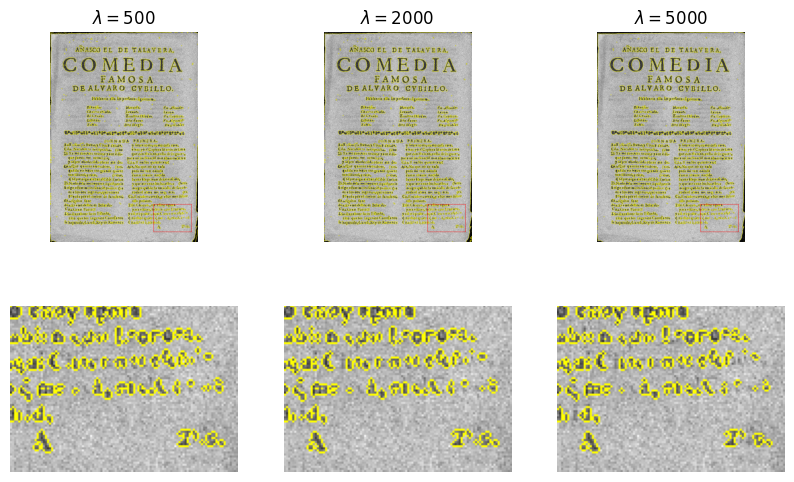

In [3]:
# lambda = 500
result_lambda500 = localtwophase(noisy_manuscript, 500, 20000, 15)
result_lambda500_edge = segmentation.mark_boundaries(noisy_manuscript, result_lambda500.astype(int))
result_lambda500_edge2 = segmentation.mark_boundaries(noisy_manuscript[500:581, 300:411], result_lambda500[500:581, 300:411].astype(int))

# lambda = 2000
result_lambda2000 = localtwophase(noisy_manuscript, 2000, 20000, 15)
result_lambda2000_edge = segmentation.mark_boundaries(noisy_manuscript, result_lambda2000.astype(int))
result_lambda2000_edge2 = segmentation.mark_boundaries(noisy_manuscript[500:581, 300:411], result_lambda2000[500:581, 300:411].astype(int))


# lambda = 5000
result_lambda5000 = localtwophase(noisy_manuscript, 5000, 20000, 15)
result_lambda5000_edge = segmentation.mark_boundaries(noisy_manuscript, result_lambda5000.astype(int))
result_lambda5000_edge2 = segmentation.mark_boundaries(noisy_manuscript[500:581, 300:411], result_lambda5000[500:581, 300:411].astype(int))

result_lambda500_edge = Image.fromarray(np.uint8(result_lambda500_edge*255))
draw = ImageDraw.Draw(result_lambda500_edge)
draw.rectangle([(x1, y1), (x2, y2)], outline='red', width=1)

result_lambda2000_edge = Image.fromarray(np.uint8(result_lambda2000_edge*255))
draw = ImageDraw.Draw(result_lambda2000_edge)
draw.rectangle([(x1, y1), (x2, y2)], outline='red', width=1)

result_lambda5000_edge = Image.fromarray(np.uint8(result_lambda5000_edge*255))
draw = ImageDraw.Draw(result_lambda5000_edge)
draw.rectangle([(x1, y1), (x2, y2)], outline='red', width=1)


# plot result
plt.figure(figsize=(10,6))
plt.subplot(2,3,1)
plt.imshow(result_lambda500_edge)
plt.axis('off')
plt.title(r'$\lambda =500$')
plt.subplot(2,3,4)
plt.imshow(result_lambda500_edge2)
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(result_lambda2000_edge)
plt.axis('off')
plt.title(r'$\lambda =2000$')
plt.subplot(2,3,5)
plt.imshow(result_lambda2000_edge2)
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(result_lambda5000_edge)
plt.axis('off')
plt.title(r'$\lambda =5000$')
plt.subplot(2,3,6)
plt.imshow(result_lambda5000_edge2)
plt.axis('off')

# Parameter: Beta

Number of iterations completed: 17 

Energy: 13339630.859682217 
 

Number of iterations completed: 19 

Energy: 20298442.71217932 
 

Number of iterations completed: 13 

Energy: 82898972.31585546 
 



(np.float64(-0.5), np.float64(110.5), np.float64(80.5), np.float64(-0.5))

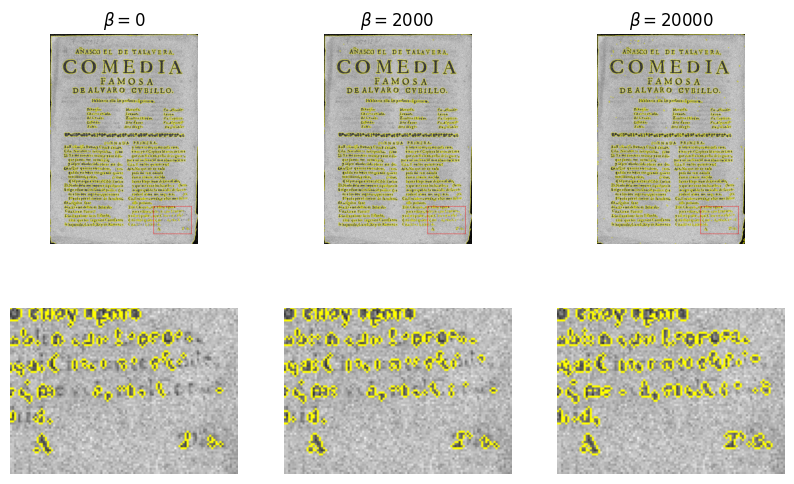

In [4]:
# beta = 0
result_beta0 = localtwophase(noisy_manuscript, 2000, 0, 15)
result_beta0_edge = segmentation.mark_boundaries(noisy_manuscript, result_beta0.astype(int))
result_beta0_edge2 = segmentation.mark_boundaries(noisy_manuscript[500:581, 300:411], result_beta0[500:581, 300:411].astype(int))

# beta = 2000
result_beta2000 = localtwophase(noisy_manuscript, 2000, 2000, 15)
result_beta2000_edge = segmentation.mark_boundaries(noisy_manuscript, result_beta2000.astype(int))
result_beta2000_edge2 = segmentation.mark_boundaries(noisy_manuscript[500:581, 300:411], result_beta2000[500:581, 300:411].astype(int))


# beta = 20000
result_beta20000 = localtwophase(noisy_manuscript, 2000, 20000, 15)
result_beta20000_edge = segmentation.mark_boundaries(noisy_manuscript, result_beta20000.astype(int))
result_beta20000_edge2 = segmentation.mark_boundaries(noisy_manuscript[500:581, 300:411], result_beta20000[500:581, 300:411].astype(int))

result_beta0_edge = Image.fromarray(np.uint8(result_beta0_edge*255))
draw = ImageDraw.Draw(result_beta0_edge)
draw.rectangle([(x1, y1), (x2, y2)], outline='red', width=1)

result_beta2000_edge = Image.fromarray(np.uint8(result_beta2000_edge*255))
draw = ImageDraw.Draw(result_beta2000_edge)
draw.rectangle([(x1, y1), (x2, y2)], outline='red', width=1)

result_beta20000_edge = Image.fromarray(np.uint8(result_beta20000_edge*255))
draw = ImageDraw.Draw(result_beta20000_edge)
draw.rectangle([(x1, y1), (x2, y2)], outline='red', width=1)



# plot result
plt.figure(figsize=(10,6))
plt.subplot(2,3,1)
plt.imshow(result_beta0_edge)
plt.axis('off')
plt.title(r'$\beta =0$')
plt.subplot(2,3,4)
plt.imshow(result_beta0_edge2)
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(result_beta2000_edge)
plt.axis('off')
plt.title(r'$\beta =2000$')
plt.subplot(2,3,5)
plt.imshow(result_beta2000_edge2)
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(result_beta20000_edge)
plt.axis('off')
plt.title(r'$\beta =20000$')
plt.subplot(2,3,6)
plt.imshow(result_beta20000_edge2)
plt.axis('off')

# Parameter: dt

Number of iterations completed: 14 

Energy: 82834146.65470271 
 

Number of iterations completed: 13 

Energy: 82898972.31585546 
 

Number of iterations completed: 23 

Energy: 83109296.20528047 
 



(np.float64(-0.5), np.float64(110.5), np.float64(80.5), np.float64(-0.5))

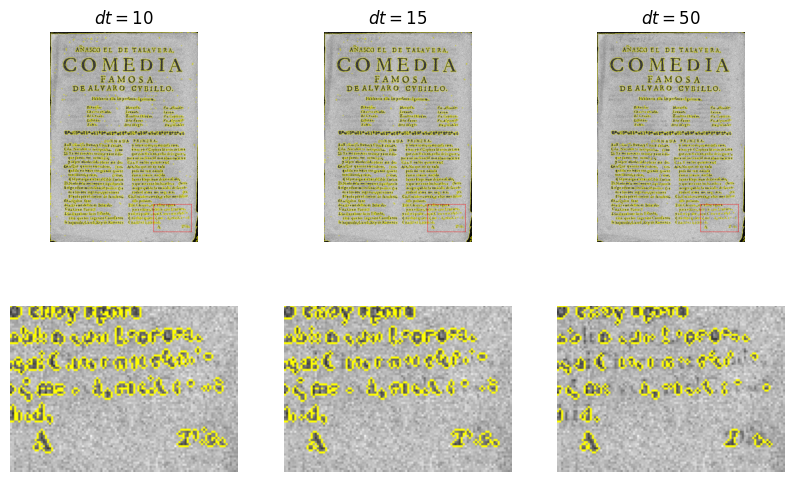

In [5]:
# dt = 10 
result_dt10 = localtwophase(noisy_manuscript, 2000, 20000, 10)
result_dt10_edge = segmentation.mark_boundaries(noisy_manuscript, result_dt10.astype(int))
result_dt10_edge2 = segmentation.mark_boundaries(noisy_manuscript[y1:(y2+1), x1:(x2+1)], result_dt10[y1:(y2+1), x1:(x2+1)].astype(int))


# dt = 15
result_dt15 = localtwophase(noisy_manuscript, 2000, 20000, 15)
result_dt15_edge = segmentation.mark_boundaries(noisy_manuscript, result_dt15.astype(int))
result_dt15_edge2 = segmentation.mark_boundaries(noisy_manuscript[y1:(y2+1), x1:(x2+1)], result_dt15[y1:(y2+1), x1:(x2+1)].astype(int))


# dt = 30
result_dt30 = localtwophase(noisy_manuscript, 2000, 20000, 30)
result_dt30_edge = segmentation.mark_boundaries(noisy_manuscript, result_dt30.astype(int))
result_dt30_edge2 = segmentation.mark_boundaries(noisy_manuscript[y1:(y2+1), x1:(x2+1)], result_dt30[y1:(y2+1), x1:(x2+1)].astype(int))


result_dt10_edge = Image.fromarray(np.uint8(result_dt10_edge*255))
draw = ImageDraw.Draw(result_dt10_edge)
draw.rectangle([(x1, y1), (x2, y2)], outline='red', width=1)

result_dt15_edge = Image.fromarray(np.uint8(result_dt15_edge*255))
draw = ImageDraw.Draw(result_dt15_edge)
draw.rectangle([(x1, y1), (x2, y2)], outline='red', width=1)

result_dt30_edge = Image.fromarray(np.uint8(result_dt30_edge*255))
draw = ImageDraw.Draw(result_dt30_edge)
draw.rectangle([(x1, y1), (x2, y2)], outline='red', width=1)

# plot result
plt.figure(figsize=(10,6))
plt.subplot(2,3,1)
plt.imshow(result_dt10_edge)
plt.axis('off')
plt.title(r'$dt =10$')
plt.subplot(2,3,4)
plt.imshow(result_dt10_edge2)
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(result_dt15_edge)
plt.axis('off')
plt.title(r'$dt = 15$')
plt.subplot(2,3,5)
plt.imshow(result_dt15_edge2)
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(result_dt30_edge)
plt.axis('off')
plt.title(r'$dt=50$')
plt.subplot(2,3,6)
plt.imshow(result_dt30_edge2)
plt.axis('off')